In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/online_retail_preprocessed.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (1003758, 14)


In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Year,Month,Day,Hour,DayOfWeek,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009,12,1,7,1,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,1,7,1,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,1,7,1,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009,12,1,7,1,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009,12,1,7,1,30.0


In [5]:
print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())


Dataset Shape: (1003758, 14)

Data Types:
Invoice          int64
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID        str
Country            str
Year             int64
Month            int64
Day              int64
Hour             int64
DayOfWeek        int64
TotalAmount    float64
dtype: object

Missing Values:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
Year           0
Month          0
Day            0
Hour           0
DayOfWeek      0
TotalAmount    0
dtype: int64


In [6]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("InvoiceDate type:", df["InvoiceDate"].dtype)
print("Date range:", df["InvoiceDate"].min(), "to", df["InvoiceDate"].max())

InvoiceDate type: datetime64[us]
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


In [7]:
df[["Quantity", "Price", "TotalAmount"]].describe()

,Quantity,Price,TotalAmount
count,1.003758e+06,1.003758e+06,1.003758e+06
mean,1.114681e+01,3.354736e+00,1.958673e+01
std,1.287125e+02,4.823730e+00,1.999426e+02
min,1.000000e+00,1.000000e-03,1.000000e-03
25%,1.000000e+00,1.250000e+00,4.130000e+00
50%,4.000000e+00,2.100000e+00,1.008000e+01
75%,1.200000e+01,4.130000e+00,1.770000e+01
max,8.099500e+04,1.157150e+03,1.684696e+05


In [8]:
df[["Quantity", "Price", "TotalAmount"]].describe()

,Quantity,Price,TotalAmount
count,1.003758e+06,1.003758e+06,1.003758e+06
mean,1.114681e+01,3.354736e+00,1.958673e+01
std,1.287125e+02,4.823730e+00,1.999426e+02
min,1.000000e+00,1.000000e-03,1.000000e-03
25%,1.000000e+00,1.250000e+00,4.130000e+00
50%,4.000000e+00,2.100000e+00,1.008000e+01
75%,1.200000e+01,4.130000e+00,1.770000e+01
max,8.099500e+04,1.157150e+03,1.684696e+05


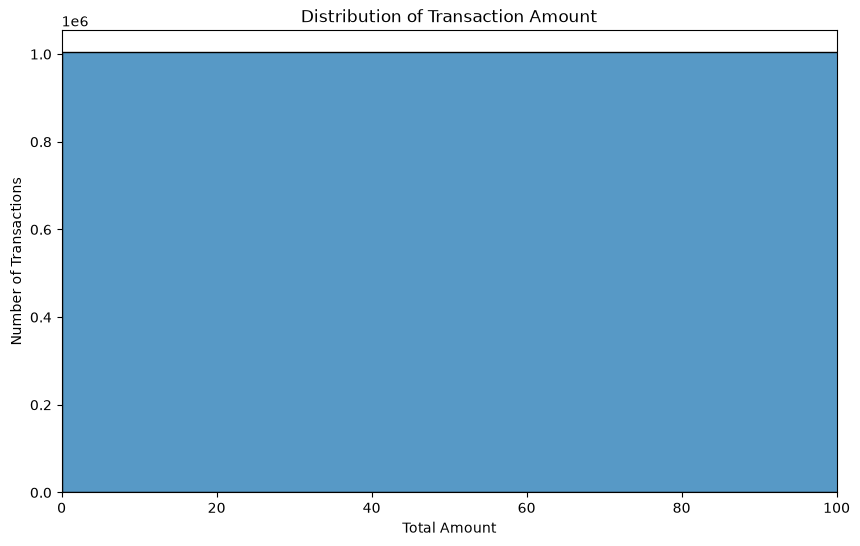

In [9]:
plt.figure(figsize=(10, 6))

sns.histplot(df["TotalAmount"], bins=50)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Total Amount")
plt.ylabel("Number of Transactions")
plt.xlim(0, 100)

plt.show()

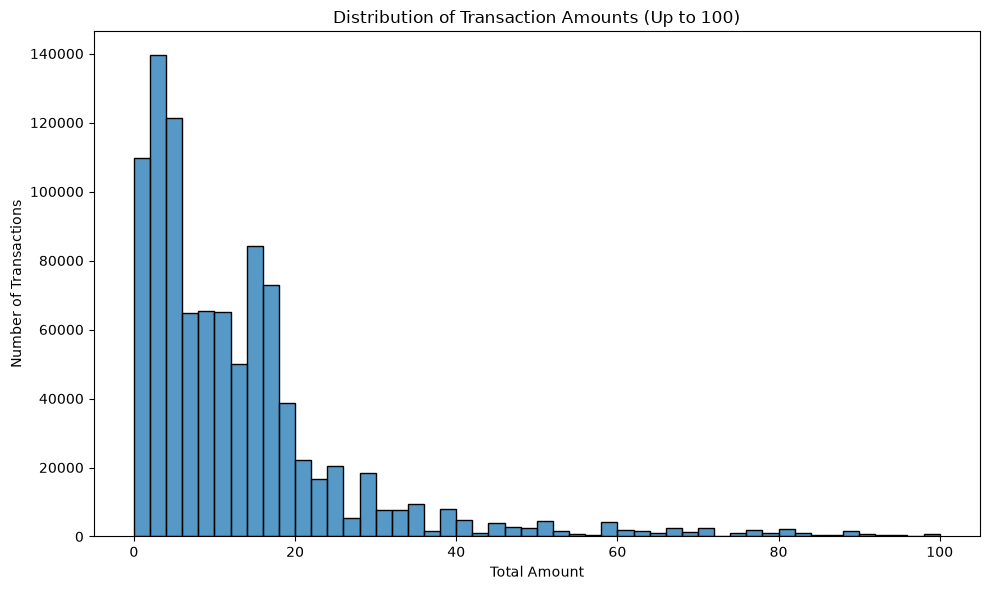

In [10]:
plt.figure(figsize=(10, 6))

sales_view = df[df["TotalAmount"] <= 100]

sns.histplot(sales_view["TotalAmount"], bins=50)

plt.title("Distribution of Transaction Amounts (Up to 100)")
plt.xlabel("Total Amount")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

In [11]:
monthly_sales = df.groupby(
    df["InvoiceDate"].dt.to_period("M")
)["TotalAmount"].sum()

monthly_sales.head()

InvoiceDate
2009-12    798747.030
2010-01    612605.502
2010-02    538147.646
2010-03    762148.531
2010-04    647004.492
Freq: M, Name: TotalAmount, dtype: float64

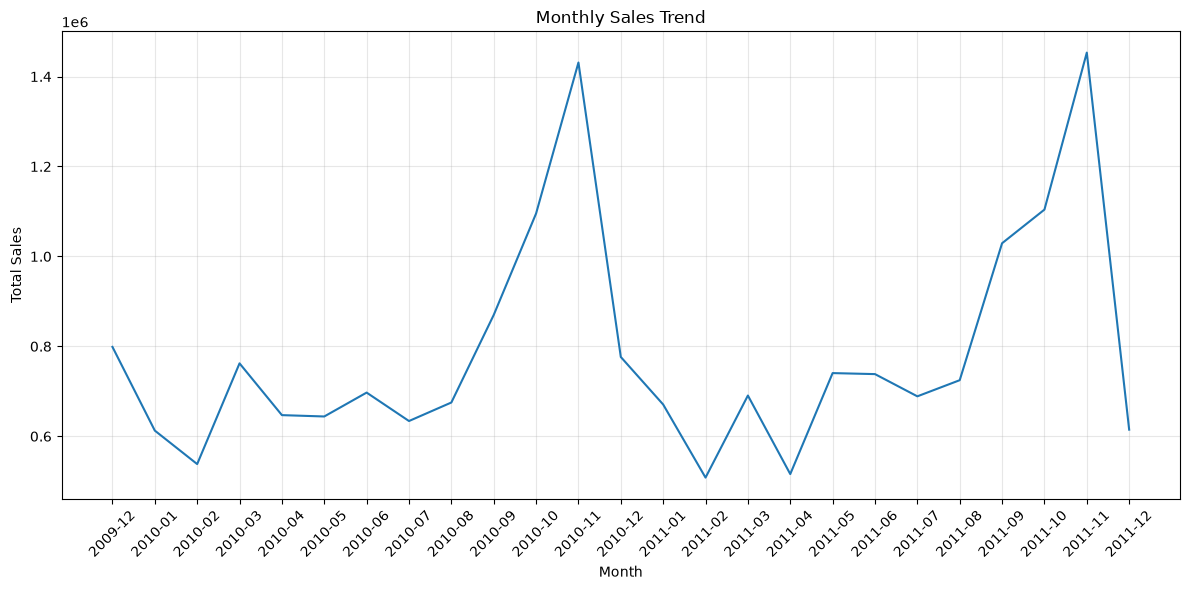

In [12]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [13]:
country_sales = (
    df.groupby("Country")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
)

country_sales.head(10)

Country
United Kingdom    1.680693e+07
EIRE              6.332842e+05
Netherlands       5.497734e+05
Germany           3.832890e+05
France            3.114863e+05
Australia         1.678000e+05
Spain             9.776675e+04
Switzerland       9.402459e+04
Sweden            8.631914e+04
Denmark           6.742269e+04
Name: TotalAmount, dtype: float64

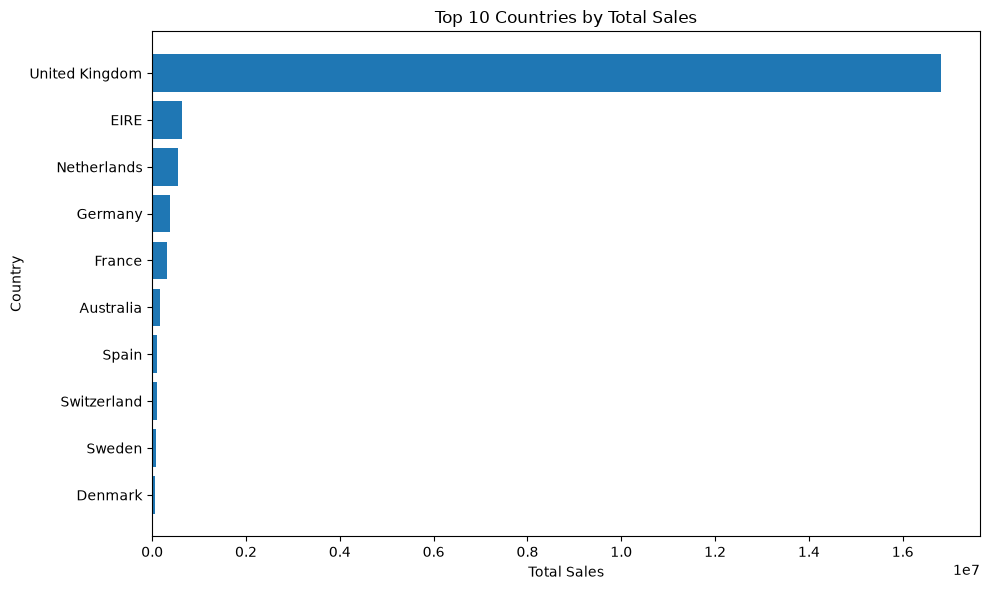

In [14]:
top_countries = country_sales.head(10).sort_values()

plt.figure(figsize=(10, 6))

plt.barh(
    top_countries.index,
    top_countries.values
)

plt.title("Top 10 Countries by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

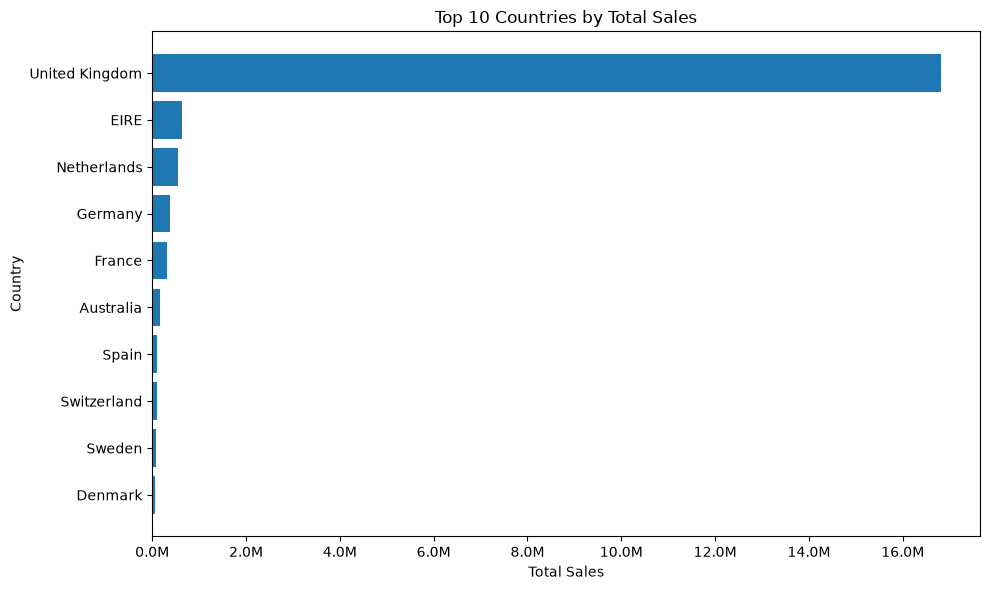

In [15]:
from matplotlib.ticker import FuncFormatter

top_countries = country_sales.head(10).sort_values()

plt.figure(figsize=(10, 6))

plt.barh(top_countries.index, top_countries.values)

plt.title("Top 10 Countries by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Country")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1e6:.1f}M")
)

plt.tight_layout()
plt.show()

In [16]:
top_products = (
    df.groupby("Description")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
)

top_products.head(10)


Description
REGENCY CAKESTAND 3 TIER               330590.32
WHITE HANGING HEART T-LIGHT HOLDER     260990.22
PAPER CRAFT , LITTLE BIRDIE            168469.60
PARTY BUNTING                          148318.28
JUMBO BAG RED RETROSPOT                148073.47
ASSORTED COLOUR BIRD ORNAMENT          129324.49
PAPER CHAIN KIT 50'S CHRISTMAS         117760.29
MEDIUM CERAMIC TOP STORAGE JAR          81700.92
CHILLI LIGHTS                           80540.88
ROTATING SILVER ANGELS T-LIGHT HLDR     71300.40
Name: TotalAmount, dtype: float64

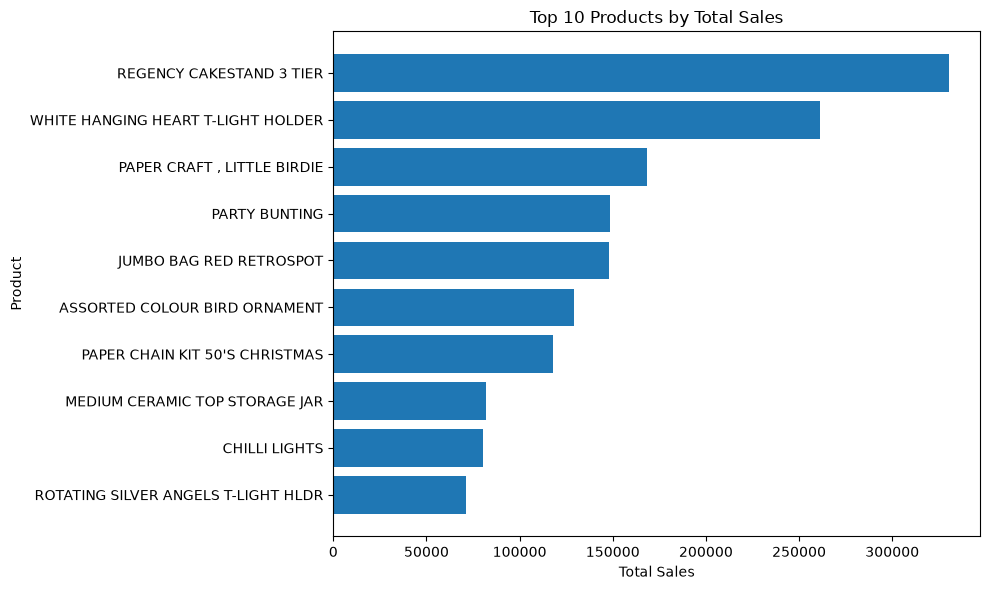

In [17]:
top_products = top_products.head(10).sort_values()

plt.figure(figsize=(10, 6))

plt.barh(top_products.index, top_products.values)

plt.title("Top 10 Products by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [18]:
day_sales = (
    df.groupby("DayOfWeek")["TotalAmount"]
    .sum()
)

day_sales

DayOfWeek
0    3420072.826
1    3882657.802
2    3378042.873
3    4014166.072
4    3169608.123
5       9803.050
6    1785988.092
Name: TotalAmount, dtype: float64

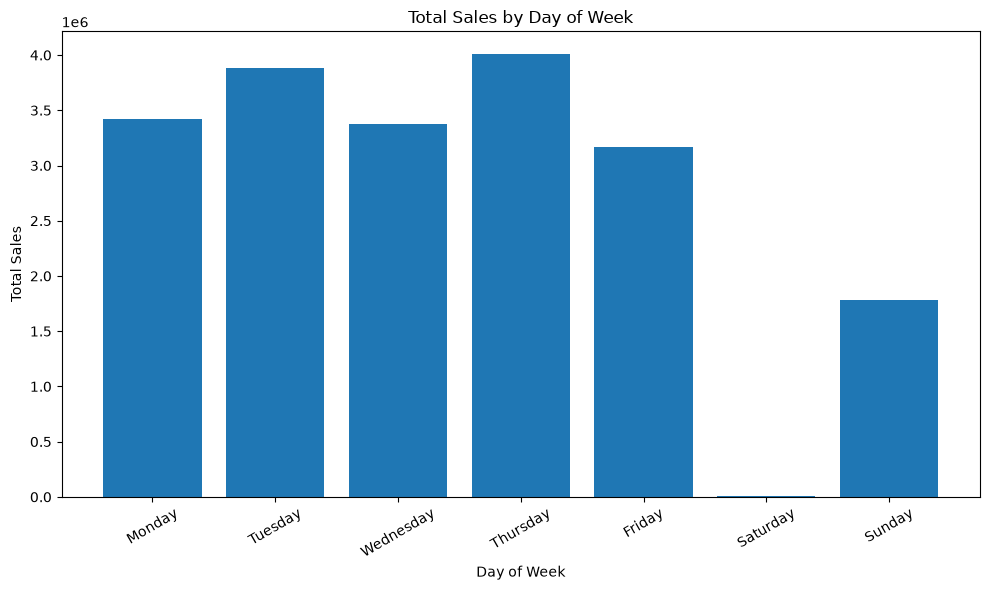

In [19]:
day_names = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

day_sales_named = day_sales.rename(index=day_names)

plt.figure(figsize=(10, 6))

plt.bar(day_sales_named.index, day_sales_named.values)

plt.title("Total Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Total Sales")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [20]:
day_counts = df["DayOfWeek"].value_counts().sort_index()

day_counts_named = day_counts.rename(index=day_names)

day_counts_named

DayOfWeek
Monday       178827
Tuesday      185551
Wednesday    172356
Thursday     189703
Friday       145266
Saturday        400
Sunday       131655
Name: count, dtype: int64

In [21]:
avg_day_sales = (
    df.groupby("DayOfWeek")["TotalAmount"]
    .mean()
    .rename(index=day_names)
)

avg_day_sales

DayOfWeek
Monday       19.125036
Tuesday      20.925017
Wednesday    19.599218
Thursday     21.160267
Friday       21.819339
Saturday     24.507625
Sunday       13.565669
Name: TotalAmount, dtype: float64

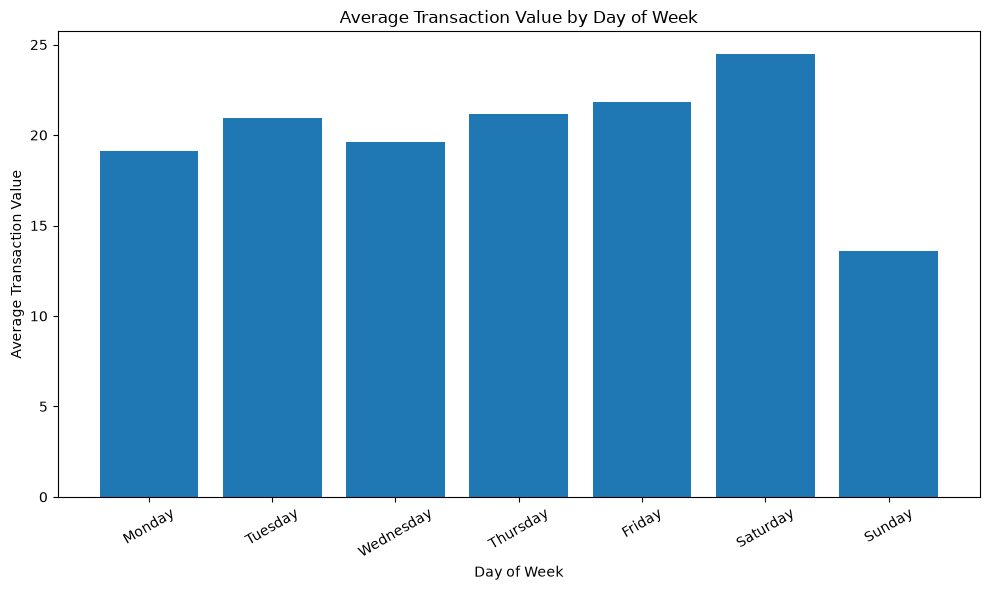

In [22]:
plt.figure(figsize=(10, 6))

plt.bar(avg_day_sales.index, avg_day_sales.values)

plt.title("Average Transaction Value by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Transaction Value")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [23]:
customer_sales = (
    df[df["Customer ID"] != "Unknown"]
    .groupby("Customer ID")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
)

customer_sales.head(10)

Customer ID
18102.0    580987.04
14646.0    526751.52
14156.0    304719.88
14911.0    279492.79
17450.0    244784.25
13694.0    195640.69
17511.0    172132.87
16446.0    168472.50
16684.0    147142.77
12415.0    144033.37
Name: TotalAmount, dtype: float64

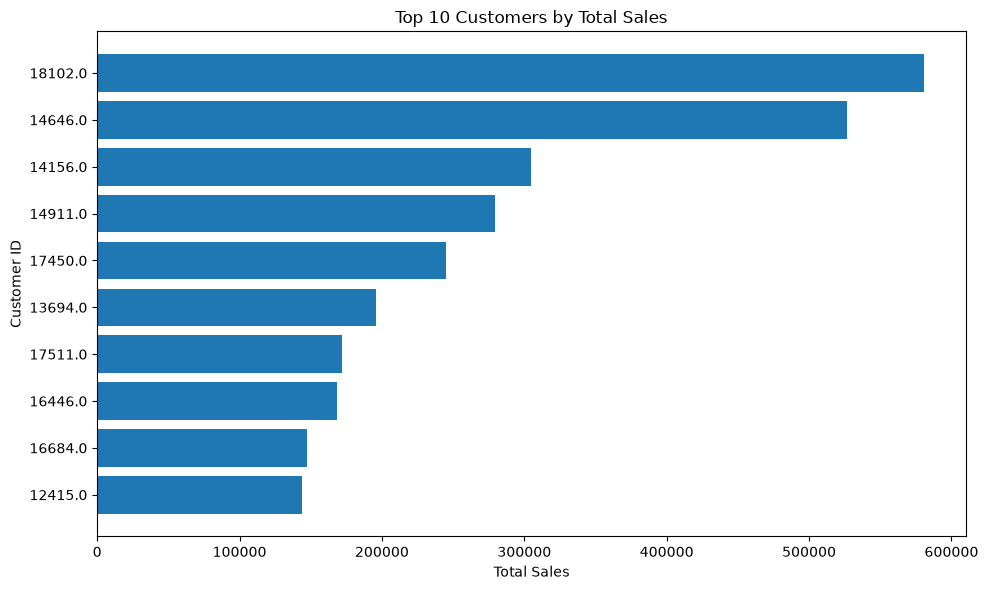

In [24]:
top_customers = customer_sales.head(10).sort_values()

plt.figure(figsize=(10, 6))

plt.barh(
    top_customers.index.astype(str),
    top_customers.values
)

plt.title("Top 10 Customers by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Customer ID")

plt.tight_layout()
plt.show()

In [25]:
corr = df[["Quantity", "Price", "TotalAmount"]].corr()

corr


,Quantity,Price,TotalAmount
Quantity,1.000000,-0.028682,0.832294
Price,-0.028682,1.000000,0.055150
TotalAmount,0.832294,0.055150,1.000000


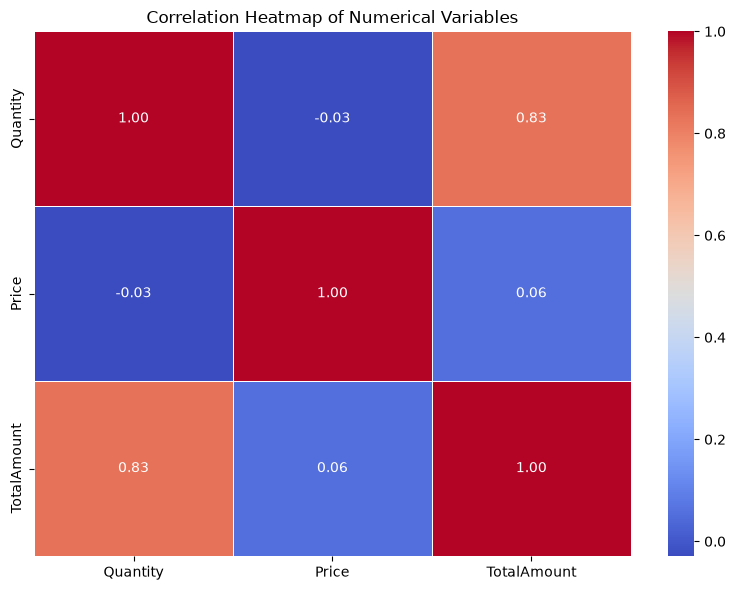

In [26]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

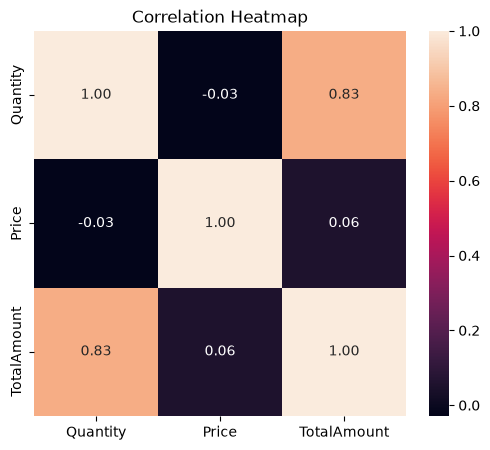

In [27]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [28]:
hourly_sales = df.groupby("Hour")["TotalAmount"].sum()

hourly_sales

Hour
6           4.250
7       75079.570
8      522595.200
9     1706158.331
10    2511169.133
11    2424890.673
12    2787660.931
13    2482022.024
14    2218494.951
15    2230116.022
16    1458671.181
17     815620.152
18     263448.920
19     125519.610
20      38887.890
Name: TotalAmount, dtype: float64

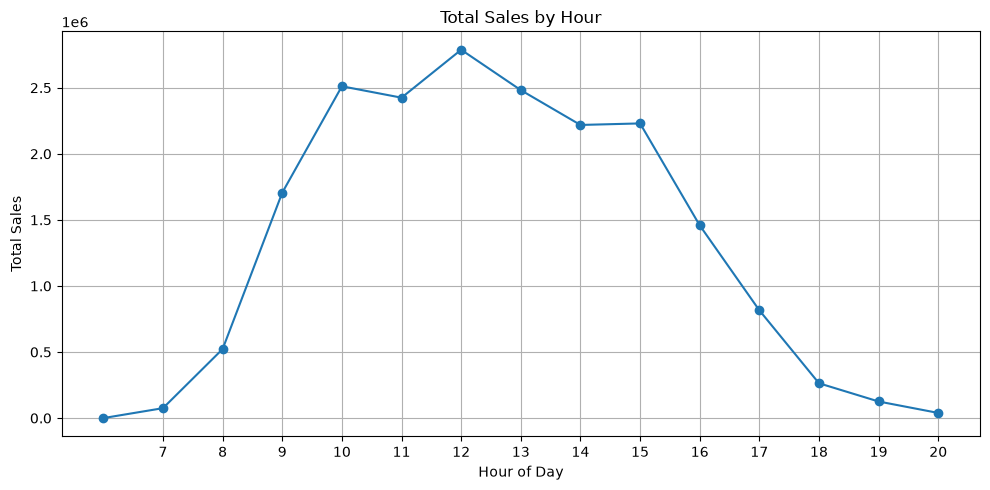

In [29]:
plt.figure(figsize=(10, 5))

plt.plot(hourly_sales.index, hourly_sales.values, marker="o")

plt.title("Total Sales by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Total Sales")
plt.xticks(range(7, 21))
plt.grid(True)

plt.tight_layout()
plt.show()

In [30]:
print("Final EDA Dataset Shape:", df.shape)
print("Total Sales:", round(df["TotalAmount"].sum(), 2))
print("Total Products:", df["Description"].nunique())
print("Total Countries:", df["Country"].nunique())
print("Total Customers:", df[df["Customer ID"] != "Unknown"]["Customer ID"].nunique())

Final EDA Dataset Shape: (1003758, 14)
Total Sales: 19660338.84
Total Products: 5350
Total Countries: 43
Total Customers: 5853
